# Cookie Cats: did moving the progression gate hurt retention?

**Recommendation: do not ship.** Moving the first progression gate from level 30 to level 40
reduced 7-day retention by **0.82 percentage points** (19.02% → 18.20%, a 4.3% relative fall,
95% CI [−1.33, −0.31]pp, p = 0.0016). The effect survives correction for testing two horizons.
Day-1 retention also fell, by 0.59pp, but that interval crosses zero — it is *inconclusive*,
not evidence of no harm.

One validity caveat travels with every number below: the arms arrived **49.56 / 50.44** against
an intended 50/50, a sample ratio mismatch at p = 0.0086. See section 4.

---

### How to read this notebook

The order of the sections is the argument. Sections 1–4 fix the design and check the
randomisation, and they do this **without the outcome columns loaded into memory at all** —
the first `read_csv` below deliberately takes only `userid` and `version`. The outcomes do not
appear until section 5.

That is not decoration. An analysis that decides what counts as success *after* seeing the
results can justify almost any conclusion, and the only defence is a design you cannot
retro-fit. Making it structural means you can see the discipline rather than take my word for it.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from abtest import (
    bootstrap_diff,
    mde_at_n,
    required_n_per_arm,
    srm_check,
    two_proportion_test,
)

DATA = ROOT / "data" / "raw" / "cookie_cats.csv"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

CONTROL, TREATMENT = "gate_30", "gate_40"
SEED = 42

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
})
INK, WARN, GOOD = "#1f2933", "#c0392b", "#1a7f5a"

## 1. Hypothesis and metrics

Most bad experiments are bad here, before any statistics happen.

**The change.** Cookie Cats is a match-three mobile game with progression gates — points where
the player must either wait or invite friends before continuing. The first gate sat at level 30.
The experiment moved it to level 40 for a randomly assigned half of 90,189 new installs.

**Hypothesis, stated so it can be wrong.** Moving the first gate from level 30 to level 40 does
not change 7-day retention. I will reject this if a two-sided test on 7-day retention clears
α = 0.05 after correcting for the two horizons I am testing.

**Metric hierarchy, fixed now.** One primary metric, because two primaries means no primary:

| Role | Metric | Why |
|---|---|---|
| **Primary** | `retention_7` — player returned 7 days after install | Matches the decision horizon. A gate is a retention mechanic; whether it works is a question about the following week, not the following morning. |
| Secondary | `retention_1` — player returned 1 day after install | Faster signal, but a gate at level 30 is out of reach for most players on day 1, so this metric is mostly diluted. |
| Guardrail | Mean and median `sum_gamerounds` | Retention could hold while engagement collapses. |
| Guardrail | Share of players with zero rounds | A canary for a broken build: if one arm has more installs that never play, something is wrong with the app, not the gate. |
| Validity check | Sample ratio | Not a result. If this fails, nothing else is trustworthy. |

A guardrail is a metric that cannot get worse *even if the primary metric wins*. It encodes the
costs you are not willing to pay for the win. If the treatment lifted 7-day retention but halved
rounds played, it would have found a way to keep people installed while making the game worse,
and I would fail the experiment on the guardrail.

**Decision rule, also fixed now.** Ship only if 7-day retention improves significantly and no
guardrail degrades. A null result is not a reason to ship; the change has engineering and
support costs, so the default is to keep what we have.

In [2]:
# Deliberately narrow: this is the design phase, so the outcome columns are not loaded.
assignment = pd.read_csv(DATA, usecols=["userid", "version"])

print(f"Users: {len(assignment):,}")
print(f"Columns in memory: {list(assignment.columns)}")
print(f"Duplicate user ids: {assignment.userid.duplicated().sum()}")
print()
print(assignment.version.value_counts().to_string())

Users: 90,189
Columns in memory: ['userid', 'version']
Duplicate user ids: 0

version
gate_40    45489
gate_30    44700


90,189 users, one row each, no duplicates — so this is unit-of-randomisation data at the user
level, which is what the tests below assume. If the same user appeared twice, the independence
assumption behind every p-value in this notebook would be broken.

## 2. Power analysis — before I have seen a single outcome

Power analysis answers: *how small an effect could this experiment see, if one were there?*
Running it afterwards is pointless — at that stage you already know the answer and the
calculation becomes a rationalisation. So it happens here, while the outcome columns are still
on disk.

The baseline rates below are the published Cookie Cats benchmarks (~45% day-1, ~19% day-7), the
kind of number you would take from a dashboard when planning. The sample size is already fixed
by the data I was given, so I ask the question in both directions:

1. Given ~44,700 users per arm, what is the smallest effect I have an 80% chance of detecting?
2. To detect an effect I would genuinely care about commercially, how many users would I need?

In [3]:
BASELINE = {"retention_1": 0.45, "retention_7": 0.19}
N_PER_ARM = int(assignment.version.value_counts().min())
POWER, ALPHA = 0.80, 0.05

rows = []
for metric, base in BASELINE.items():
    abs_mde, rel_mde = mde_at_n(base, N_PER_ARM, power=POWER, alpha=ALPHA, direction="decrease")
    rows.append({
        "metric": metric,
        "assumed baseline": f"{base:.1%}",
        "n per arm": f"{N_PER_ARM:,}",
        "detectable drop (pp)": f"{abs_mde * 100:.2f}",
        "detectable drop (relative)": f"{rel_mde:.2%}",
    })

mde_table = pd.DataFrame(rows)
print(f"Smallest effect detectable at {POWER:.0%} power, alpha={ALPHA}:\n")
print(mde_table.to_string(index=False))

Smallest effect detectable at 80% power, alpha=0.05:

     metric assumed baseline n per arm detectable drop (pp) detectable drop (relative)
retention_1            45.0%    44,700                -0.93                     -2.07%
retention_7            19.0%    44,700                -0.73                     -3.84%


In [4]:
# The other direction: sample size needed for effects we might actually care about.
targets = [-0.01, -0.02, -0.03, -0.05]
need = pd.DataFrame(
    {
        f"{t:.0%} relative": {
            m: f"{required_n_per_arm(b, t, power=POWER, alpha=ALPHA):,.0f}"
            for m, b in BASELINE.items()
        }
        for t in targets
    }
)
print("Users required PER ARM to detect a given relative drop at 80% power:\n")
print(need.to_string())
print(f"\nActually available per arm: {N_PER_ARM:,}")

Users required PER ARM to detect a given relative drop at 80% power:

            -1% relative -2% relative -3% relative -5% relative
retention_1      191,681       47,873       21,254        7,634
retention_7      666,650      166,016       73,496       26,249

Actually available per arm: 44,700


**This experiment is underpowered for its own primary metric, and I am recording that before
I look at any result.**

With ~44,700 users per arm I can detect a 3.8% relative fall in 7-day retention. A 1% relative
fall — which on a game this size is real money — would need roughly 670,000 users per arm,
fifteen times what I have. So a null result on day 7 will not mean "no effect". It will mean
"no effect larger than about 4%", which is a much weaker claim and must be reported as such.

Day-1 retention is better served: its higher baseline (45% versus 19%) means the same sample
resolves a 2.1% relative change.

Note that the detectable *drop* and detectable *rise* are not the same size. The effect size
behind this calculation is Cohen's h, which is not symmetric: from a 19% baseline, a rise moves
the rate toward 50% where the variance p(1−p) is larger, and so needs a larger sample. Quoting
the wrong direction makes a power calculation quietly optimistic. `mde_at_n` takes an explicit
`direction` argument for that reason, and I have asked for the direction I actually fear.

## 3. Why the sample size has to be fixed in advance

The rule is: decide the sample size, collect it, look once. The reason is worth demonstrating
rather than asserting, because it is the single most common way a real experiment lies.

Suppose you watch the dashboard and stop as soon as p < 0.05. Every check is another chance to
cross the line, and random walks cross lines. Below I run 1,000 experiments in which **there is
genuinely no effect** — both arms drawn from the identical 19% rate — and check each one at ten
points as data accumulates, stopping at the first significant result.

Since every one of these experiments is null by construction, every "significant" result is a
false positive. A correctly calibrated procedure should produce about 5%.

In [5]:
def peeking_simulation(n_per_arm, rate, n_checks=10, n_sims=1000, alpha=0.05, seed=SEED):
    """Run null experiments, checking repeatedly, and record the first significant look."""
    rng = np.random.default_rng(seed)
    step = n_per_arm // n_checks

    # Users arrive in batches; cumulative successes are the running totals.
    c = np.cumsum(rng.binomial(step, rate, (n_sims, n_checks)), axis=1)
    t = np.cumsum(rng.binomial(step, rate, (n_sims, n_checks)), axis=1)
    n = np.arange(1, n_checks + 1) * step

    p_pool = (c + t) / (2 * n)
    se = np.sqrt(p_pool * (1 - p_pool) * (2 / n))
    z = np.divide(t / n - c / n, se, out=np.zeros_like(se), where=se > 0)
    p = 2 * norm.sf(np.abs(z))

    significant = p < alpha
    peeked = significant.any(axis=1)          # stopped early at ANY look
    honest = significant[:, -1]               # looked only once, at the end
    return peeked.mean(), honest.mean(), significant


peeked_rate, honest_rate, sig_matrix = peeking_simulation(N_PER_ARM, BASELINE["retention_7"])

print(f"1,000 null experiments, 10 looks each, nominal alpha = 5%\n")
print(f"  Looked once at the planned sample size : {honest_rate:.1%} false positives")
print(f"  Stopped at the first significant look  : {peeked_rate:.1%} false positives")
print(f"\n  Inflation factor: {peeked_rate / honest_rate:.1f}x")

1,000 null experiments, 10 looks each, nominal alpha = 5%

  Looked once at the planned sample size : 4.9% false positives
  Stopped at the first significant look  : 19.4% false positives

  Inflation factor: 4.0x


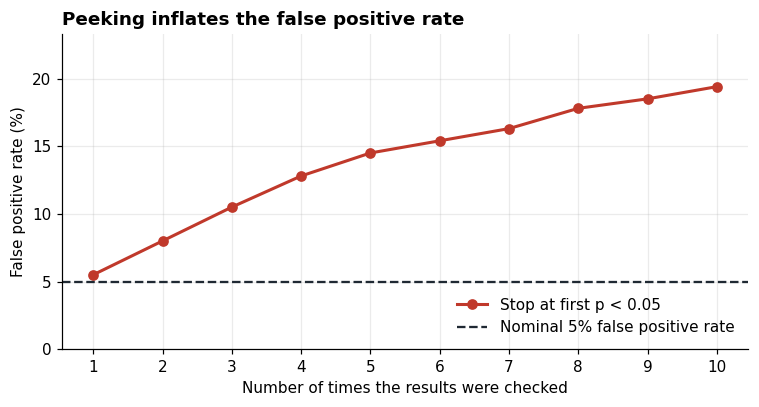

In [6]:
cumulative = np.maximum.accumulate(sig_matrix, axis=1).mean(axis=0)
looks = np.arange(1, len(cumulative) + 1)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(looks, cumulative * 100, marker="o", color=WARN, lw=2, label="Stop at first p < 0.05")
ax.axhline(5, color=INK, ls="--", lw=1.5, label="Nominal 5% false positive rate")
ax.set_xlabel("Number of times the results were checked")
ax.set_ylabel("False positive rate (%)")
ax.set_title("Peeking inflates the false positive rate", loc="left", fontweight="bold")
ax.set_xticks(looks)
ax.set_ylim(0, max(cumulative * 100) * 1.2)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "peeking.png", dpi=150, bbox_inches="tight")
plt.show()

**In one sentence:** if you check a null experiment ten times and stop the moment it looks
significant, you will call it a winner about one time in five instead of one in twenty.

The curve is the whole argument. Nothing about the data changed between look one and look ten —
the effect was zero throughout. What changed is the number of opportunities to be unlucky.

This is why the sample size gets fixed in advance: it converts "look until it works" into a
single pre-committed test with the error rate it advertises. If you genuinely need to monitor an
experiment as it runs — and often you do, to catch harm early — the honest way is a method that
budgets for the looks, such as sequential testing with alpha spending or always-valid confidence
sequences. What you cannot do is peek with a fixed-horizon test and report the nominal p-value.

## 4. Sample ratio mismatch — the first thing to check, and the first thing people skip

Before trusting any comparison, check that the randomisation delivered the split it promised.
A 50/50 assignment should produce arms of near-equal size; a meaningful deviation means users
were *not* assigned the way you think, and once that is true every downstream number is
measuring the assignment bug rather than the treatment.

This is a check on the data collection, not on the model — which is why it comes before the
model. It is also cheap: one chi-square test on two integers.

In [7]:
counts = assignment.version.value_counts().to_dict()
srm = srm_check(counts, expected_ratio={CONTROL: 0.5, TREATMENT: 0.5})

print(srm)
print()
print(f"  Intended split : 50.00% / 50.00%")
print(f"  Observed split : " + " / ".join(f"{s:.2%}" for s in srm.observed_share.values()))
print(f"  Excess users in {TREATMENT}: {counts[TREATMENT] - counts[CONTROL]:,}")
print()
print(f"  Verdict at alpha = 0.05  : {srm.verdict(0.05)}")
print(f"  Verdict at alpha = 0.001 : {srm.verdict(0.001)}")

SRM: gate_40=45,489, gate_30=44,700 | observed split 50.44%/49.56% | chi2=6.902, p=0.00861

  Intended split : 50.00% / 50.00%
  Observed split : 50.44% / 49.56%
  Excess users in gate_40: 789

  Verdict at alpha = 0.05  : FAIL - investigate
  Verdict at alpha = 0.001 : pass


**This is a genuine flag, and it sits in one of the most-analysed public A/B datasets there is.**

p = 0.0086. If the split were truly 50/50, an imbalance this large or larger would happen
roughly once in 116 experiments. That is unlikely enough to notice and not so unlikely as to be
conclusive — so the decision depends on the threshold, and the threshold deserves a reason.

The usual industry choice is α ≈ 0.001, not 0.05. The reason is that SRM is checked on *every*
experiment: at 0.05, a platform running a thousand experiments a year would raise fifty false
alarms, teams would learn to ignore the alert, and the check would stop working. So this result
**fails at 0.05 and passes at 0.001**.

What I would actually do, in order:

1. **Not silently proceed.** Take it to whoever owns the assignment service.
2. **Look for a mechanism.** SRM is usually a bug, not bad luck. The classic causes are
   differential drop-out before logging (the treatment build is slower to load, so more users
   bounce before the install event fires), a broken hash or an off-by-one in bucket boundaries,
   a redirect that only one arm goes through, or bot traffic landing unevenly.
3. **Check whether the imbalance is plausibly harmless.** Here the *larger* arm is the
   treatment. Differential drop-out normally shrinks the arm with the worse experience, so the
   more common pattern would be the opposite. That is mild reassurance, not a clean bill of
   health.
4. **Proceed, flagged.** I report the results with the caveat attached rather than dropping the
   analysis — but if the day-7 result had been a marginal *win*, I would not ship on it. A
   caveat weighs differently depending on which way it cuts.

The reason this matters more than its two lines of code suggest: an SRM can manufacture a
retention difference out of nothing. If the treatment build silently failed to register some
slow-connecting users, those users are missing from the data *and* would have been the least
likely to return — so the treatment arm looks artificially healthy. Checking the split first is
how you avoid explaining a logging bug as a behavioural insight.

## 5. Now — and only now — the outcomes

The design is fixed: one primary metric, a known detectable effect, and a randomisation check
that is flagged but not disqualifying. Only at this point do the outcome columns get loaded.

I report the **confidence interval first**, then the p-value. The interval carries the effect
size and the uncertainty together and answers the question a decision-maker actually has — *how
big could this be, at worst and at best?* A p-value on its own answers a narrower question and
is routinely mistaken for an answer to the wider one.

In [8]:
df = pd.read_csv(DATA)
df["version"] = pd.Categorical(df["version"], categories=[CONTROL, TREATMENT])

METRICS = ["retention_7", "retention_1"]   # primary first
results = {}

for metric in METRICS:
    grouped = df.groupby("version", observed=True)[metric].agg(["sum", "count"])
    results[metric] = two_proportion_test(
        control_successes=int(grouped.loc[CONTROL, "sum"]),
        control_n=int(grouped.loc[CONTROL, "count"]),
        treatment_successes=int(grouped.loc[TREATMENT, "sum"]),
        treatment_n=int(grouped.loc[TREATMENT, "count"]),
        metric=metric,
    )

summary = pd.DataFrame([
    {
        "metric": r.metric,
        "role": "PRIMARY" if r.metric == "retention_7" else "secondary",
        f"{CONTROL} (control)": f"{r.control_rate:.2%}",
        f"{TREATMENT} (treatment)": f"{r.treatment_rate:.2%}",
        "absolute diff": f"{r.absolute_diff * 100:+.2f}pp",
        "95% CI": f"[{r.ci_low * 100:+.2f}, {r.ci_high * 100:+.2f}]pp",
        "relative diff": f"{r.relative_diff:+.2%}",
        "p-value": f"{r.p_value:.4f}",
    }
    for r in results.values()
])
print(summary.to_string(index=False))

     metric      role gate_30 (control) gate_40 (treatment) absolute diff           95% CI relative diff p-value
retention_7   PRIMARY            19.02%              18.20%       -0.82pp [-1.33, -0.31]pp        -4.31%  0.0016
retention_1 secondary            44.82%              44.23%       -0.59pp [-1.24, +0.06]pp        -1.32%  0.0744


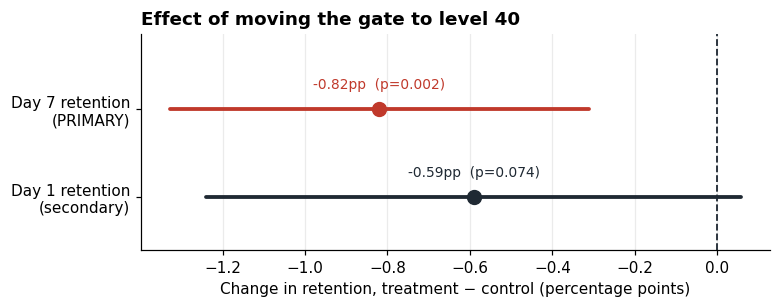

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 2.9))
order = METRICS[::-1]

for i, metric in enumerate(order):
    r = results[metric]
    colour = WARN if r.significant else INK
    ax.plot([r.ci_low * 100, r.ci_high * 100], [i, i], color=colour, lw=2.5, solid_capstyle="round")
    ax.plot(r.absolute_diff * 100, i, "o", color=colour, ms=9, zorder=3)
    ax.annotate(
        f"{r.absolute_diff * 100:+.2f}pp  (p={r.p_value:.3f})",
        (r.absolute_diff * 100, i), textcoords="offset points", xytext=(0, 13),
        ha="center", fontsize=9, color=colour,
    )

ax.axvline(0, color=INK, lw=1.2, ls="--")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(["Day 7 retention\n(PRIMARY)" if m == "retention_7" else "Day 1 retention\n(secondary)" for m in order])
ax.set_xlabel("Change in retention, treatment − control (percentage points)")
ax.set_title("Effect of moving the gate to level 40", loc="left", fontweight="bold")
ax.set_ylim(-0.6, len(order) - 0.15)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIGURES / "forest.png", dpi=150, bbox_inches="tight")
plt.show()

**Day 7 (primary).** Retention fell from 19.02% to 18.20% — a drop of 0.82pp, or 4.3% of the
baseline. The interval runs from −1.33pp to −0.31pp: entirely below zero, so the data are
inconsistent with "no effect", and the plausible range of harm spans roughly a 1.6% to 7.0%
relative fall. Even the optimistic end of that interval is a loss.

**Day 1 (secondary).** Retention fell 0.59pp, interval [−1.24, +0.06]pp, p = 0.074. This crosses
zero, so I cannot reject the null — but note what the interval does *not* say. It does not say
the effect is zero. It says the effect is somewhere between a 1.24pp fall and a 0.06pp rise, and
a 1.24pp fall would matter. The correct word is **inconclusive**, and the section 2 power
analysis told us in advance that this would be a live possibility.

That distinction is the difference between "we tested it and it's fine" and "we tested it and
couldn't tell". The first is a claim; the second is an admission. Only one of them is true here.

## 6. Bootstrap: the same answer, without the normal approximation

The z-test above assumes the sampling distribution of the difference is normal. At n ≈ 45,000
that assumption is safe, but assuming and checking are different things — and the check costs
one loop.

Resample both arms with replacement 10,000 times, recompute the difference each time, and look
at the spread of answers. No formula, no approximation: just "what would this experiment have
said, had it run again?". If the resampled interval lands on top of the analytic one, the
analytic one has earned its keep.

It also translates well. "We re-ran the experiment ten thousand times and 95% of the time the
treatment came out worse" is a sentence a non-technical stakeholder can act on, which is half of
what this job is.

In [10]:
boot = {}
for metric in METRICS:
    control_arm = df.loc[df.version == CONTROL, metric].to_numpy(dtype=float)
    treatment_arm = df.loc[df.version == TREATMENT, metric].to_numpy(dtype=float)
    dist, lo, hi = bootstrap_diff(control_arm, treatment_arm, n_resamples=10_000, seed=SEED)
    boot[metric] = (dist, lo, hi)

    analytic = results[metric]
    print(f"{metric}")
    print(f"  analytic  95% CI : [{analytic.ci_low * 100:+.3f}, {analytic.ci_high * 100:+.3f}]pp")
    print(f"  bootstrap 95% CI : [{lo * 100:+.3f}, {hi * 100:+.3f}]pp")
    print(f"  share of resamples showing harm: {(dist < 0).mean():.1%}\n")

retention_7
  analytic  95% CI : [-1.328, -0.312]pp
  bootstrap 95% CI : [-1.328, -0.321]pp
  share of resamples showing harm: 99.9%

retention_1
  analytic  95% CI : [-1.239, +0.058]pp
  bootstrap 95% CI : [-1.252, +0.056]pp
  share of resamples showing harm: 96.2%



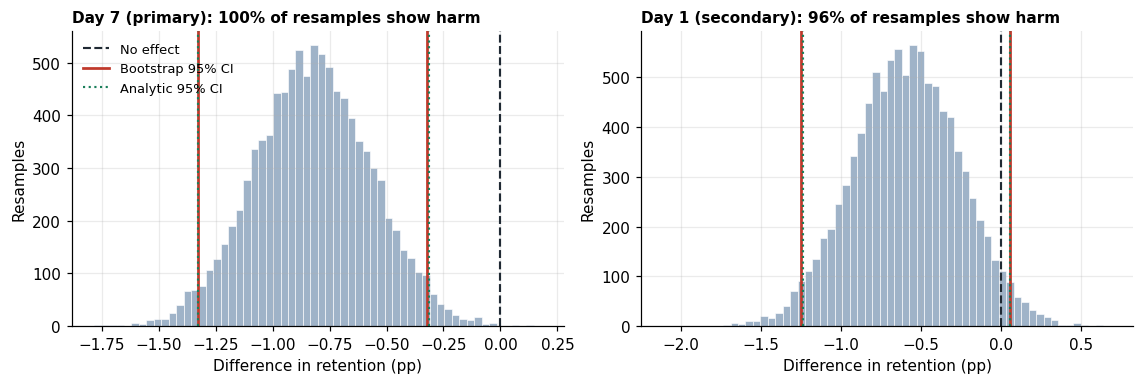

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

for ax, metric in zip(axes, METRICS):
    dist, lo, hi = boot[metric]
    analytic = results[metric]

    ax.hist(dist * 100, bins=60, color="#9fb3c8", edgecolor="white", linewidth=0.4)
    ax.axvline(0, color=INK, ls="--", lw=1.4, label="No effect")
    ax.axvline(lo * 100, color=WARN, lw=1.8, label="Bootstrap 95% CI")
    ax.axvline(hi * 100, color=WARN, lw=1.8)
    ax.axvline(analytic.ci_low * 100, color=GOOD, lw=1.4, ls=":", label="Analytic 95% CI")
    ax.axvline(analytic.ci_high * 100, color=GOOD, lw=1.4, ls=":")

    label = "Day 7 (primary)" if metric == "retention_7" else "Day 1 (secondary)"
    ax.set_title(f"{label}: {(dist < 0).mean():.0%} of resamples show harm", loc="left", fontweight="bold", fontsize=10)
    ax.set_xlabel("Difference in retention (pp)")
    ax.set_ylabel("Resamples")

axes[0].legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()

The two intervals agree to within a hundredth of a percentage point, so the normal approximation
was fine — which is the useful outcome, not a wasted check. The day-7 distribution sits almost
entirely to the left of zero; the day-1 distribution straddles it.

## 7. Multiple comparisons

I tested two horizons. Two tests at α = 0.05 give roughly a 1 − 0.95² ≈ 9.75% chance of at least
one false positive if both nulls are true. With twenty metrics it is 64%, which is to say: with
twenty metrics you are *guaranteed* a winner whether or not anything happened.

The fix is to adjust the threshold for the number of tests. **Bonferroni/Holm** controls the
chance of *any* false positive — strict, appropriate when a single wrong call is expensive, as
when deciding whether to ship. **Benjamini–Hochberg** controls the expected *proportion* of
false positives among the things you flag — more permissive, appropriate for exploratory
screening where you will follow up anyway. I use Holm for the ship decision.

In [12]:
p_values = [results[m].p_value for m in METRICS]
holm = multipletests(p_values, alpha=0.05, method="holm")
bh = multipletests(p_values, alpha=0.05, method="fdr_bh")

print(pd.DataFrame({
    "metric": METRICS,
    "raw p": [f"{p:.4f}" for p in p_values],
    "Holm p": [f"{p:.4f}" for p in holm[1]],
    "BH p": [f"{p:.4f}" for p in bh[1]],
    "significant (Holm)": holm[0],
}).to_string(index=False))

     metric  raw p Holm p   BH p  significant (Holm)
retention_7 0.0016 0.0031 0.0031                True
retention_1 0.0744 0.0744 0.0744               False


Day 7 survives: Holm-adjusted p = 0.0031. The conclusion does not depend on ignoring the second
test. Day 1 was not significant before adjustment and remains so.

### What happens when you slice until something appears

The correction above is arithmetic. The harder problem is the tests you do not count — the
segments you try after the headline result disappoints.

To show this with the answer known in advance, I attach a **purely random** segment label to
every user. It is generated from a random number generator and has no relationship to anything.
Then I run the full analysis within each segment. Every significant result below is, by
construction, a false positive.

In [13]:
rng = np.random.default_rng(SEED)
n_segments = 10
df["fake_segment"] = rng.integers(0, n_segments, len(df))

slices = []
for seg in range(n_segments):
    chunk = df[df.fake_segment == seg]
    for metric in METRICS:
        g = chunk.groupby("version", observed=True)[metric].agg(["sum", "count"])
        r = two_proportion_test(
            int(g.loc[CONTROL, "sum"]), int(g.loc[CONTROL, "count"]),
            int(g.loc[TREATMENT, "sum"]), int(g.loc[TREATMENT, "count"]),
            metric=f"segment {seg} / {metric}",
        )
        slices.append({"test": r.metric, "effect (pp)": r.absolute_diff * 100, "p": r.p_value})

sliced = pd.DataFrame(slices).sort_values("p").reset_index(drop=True)
naive_hits = (sliced.p < 0.05).sum()
bonf = multipletests(sliced.p, alpha=0.05, method="bonferroni")

print(f"{len(sliced)} subgroup tests on a segment label that is pure noise.\n")
print(f"  'Significant' at p < 0.05, uncorrected : {naive_hits}")
print(f"  Significant after Bonferroni           : {bonf[0].sum()}")
print(f"  True number of real effects            : 0\n")
print("Most extreme findings, had I gone looking:\n")
print(sliced.head(4).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

20 subgroup tests on a segment label that is pure noise.

  'Significant' at p < 0.05, uncorrected : 2
  Significant after Bonferroni           : 0
  True number of real effects            : 0

Most extreme findings, had I gone looking:

                   test  effect (pp)      p
segment 5 / retention_7      -2.1054 0.0108
segment 3 / retention_1      -2.5371 0.0160
segment 7 / retention_1      -2.0314 0.0506
segment 4 / retention_7      -1.5549 0.0546


Those top rows are what a slicing exercise produces. Each one is presentable — a segment, an
effect size, a p-value under 0.05 — and each one is noise, because the segment label was drawn
from a random number generator. Run the same search across countries, devices, acquisition
channels and tenure buckets and you will always find something.

Naming the failure modes, because interviewers ask for the names:

- **p-hacking** — searching over analyses until one clears the threshold.
- **HARKing** — Hypothesising After the Results are Known: presenting the surviving slice as
  though it had been the plan.
- **The garden of forking paths** — the subtler version, where you make one analysis choice at
  each fork, never explicitly test twenty things, and still end up with an uncontrolled error
  rate because the choices depended on the data.

The defences are unglamorous. Fix the primary metric before the data arrives (section 1).
Correct for the tests you run. Declare subgroup analyses in advance, or label them
*exploratory* and treat anything they find as a hypothesis for the next experiment rather than a
result from this one. Then re-run any finding on fresh data — a real effect replicates; a
forking-path artefact does not.

## 8. Guardrails

Declared in section 1, evaluated now. The question is not "did they win" but "did anything break".

In [14]:
guardrails = df.groupby("version", observed=True).agg(
    mean_rounds=("sum_gamerounds", "mean"),
    median_rounds=("sum_gamerounds", "median"),
    zero_round_share=("sum_gamerounds", lambda s: (s == 0).mean()),
)
print(guardrails.to_string(float_format=lambda v: f"{v:.4f}"))
print()

# The mean is not trustworthy here - one player logged 49,854 rounds.
print(f"Max rounds by a single player: {df.sum_gamerounds.max():,}")
print(f"99.9th percentile:             {df.sum_gamerounds.quantile(0.999):,.0f}")
print()

# Rank-based test: no distributional assumption, immune to that outlier.
from scipy import stats

control_rounds = df.loc[df.version == CONTROL, "sum_gamerounds"]
treatment_rounds = df.loc[df.version == TREATMENT, "sum_gamerounds"]
u_stat, u_p = stats.mannwhitneyu(treatment_rounds, control_rounds, alternative="two-sided")

# A p-value alone is not a finding. The common-language effect size says how
# often a random treatment player out-plays a random control player; 0.50 is
# "no difference at all".
a12 = u_stat / (len(treatment_rounds) * len(control_rounds))

# Second look with the tail capped, so one 49,854-round player cannot drive it.
cap = df.sum_gamerounds.quantile(0.99)
cap_c, cap_t = control_rounds.clip(upper=cap), treatment_rounds.clip(upper=cap)
cap_p = stats.ttest_ind(cap_t, cap_c, equal_var=False).pvalue

print(f"Mann-Whitney U on rounds played : p = {u_p:.4f}")
print(f"  common-language effect size   : {a12:.4f}  (0.5000 = no difference)")
print(f"  winsorised at p99 ({cap:,.0f} rounds): "
      f"{cap_c.mean():.2f} vs {cap_t.mean():.2f} rounds, p = {cap_p:.4f}")

zero_g = df.assign(zero=df.sum_gamerounds.eq(0)).groupby("version", observed=True)["zero"].agg(["sum", "count"])
zero_test = two_proportion_test(
    int(zero_g.loc[CONTROL, "sum"]), int(zero_g.loc[CONTROL, "count"]),
    int(zero_g.loc[TREATMENT, "sum"]), int(zero_g.loc[TREATMENT, "count"]),
    metric="zero-round share",
)
print(zero_test.summary())

         mean_rounds  median_rounds  zero_round_share
version                                              
gate_30      52.4563        17.0000            0.0433
gate_40      51.2988        16.0000            0.0452

Max rounds by a single player: 49,854
99.9th percentile:             1,074

Mann-Whitney U on rounds played : p = 0.0502
  common-language effect size   : 0.4962  (0.5000 = no difference)
  winsorised at p99 (493 rounds): 49.14 vs 48.85 rounds, p = 0.6152
zero-round share: 4.33% -> 4.52% | +0.189pp (95% CI [-0.080, +0.457]pp) | +4.35% relative | p=0.16857


**Rounds played** — one player recorded 49,854 rounds against a median of 16. A single user like
that can move a mean and make a t-test meaningless, so the headline test is rank-based: it asks
whether treatment players tend to play more than control players, without caring how extreme the
tail is.

It returns **p = 0.0502**. Sitting a thousandth above the threshold is a good moment to remember
that 0.05 is a convention, not a physical constant, and that "p = 0.0502, not significant" and
"p = 0.0498, significant" describe the same evidence. So I do not report this as a clean pass.
I look at the size of the thing instead:

- The common-language effect size is **0.496**, against 0.500 for no difference whatsoever. A
  random treatment player out-plays a random control player 49.6% of the time instead of 50%.
- With the top 1% of the tail capped, the arms differ by about **0.3 rounds** on a base of 49,
  at p = 0.62.
- The medians are 17 and 16.

So the guardrail is *marginal in significance and negligible in size* — which, on 90,000 users,
is what a real-but-tiny effect looks like. It leans the same way as the retention loss, which is
coherent: treatment players play a fraction less and return a little less often. It does not on
its own justify failing the experiment, and it does not rescue it either.

**Zero-round share** — indistinguishable between arms (p = 0.17). This is the canary I wanted:
if the treatment build were crashing on launch, this is where it would show, and it does not. It
also slightly weakens the differential-drop-out explanation for the SRM in section 4.

**Guardrail verdict: nothing catastrophic broke, and nothing here rescues the primary metric.**
Worth stating precisely, because it rules out the most comfortable explanation. The day-7 loss is
not a measurement artefact or a broken build. The change worked as designed and made the game
slightly worse.

## 9. Statistical significance is not practical significance

These come apart in both directions, and conflating them is how analyses become useless:

- A **statistically significant, practically irrelevant** result: at ten million users you can
  resolve a 0.001pp change. It is real. It is also worth nothing, and shipping for it costs
  engineering time you could spend elsewhere.
- A **practically enormous, statistically inconclusive** result: this experiment's day-1 number.
  The interval reaches −1.24pp, which would be a serious loss, and I cannot rule it out.

So the question is never "is p < 0.05". It is "what does the interval imply for the business,
across its whole range, and what decision does that support?"

In [15]:
r7 = results["retention_7"]
INSTALLS = 100_000     # illustrative planning figure, not from the data

print(f"Per {INSTALLS:,} new installs, shipping {TREATMENT} would mean:\n")
print(f"  point estimate : {abs(r7.absolute_diff) * INSTALLS:,.0f} fewer players still active at day 7")
print(f"  best case      : {abs(r7.ci_high) * INSTALLS:,.0f} fewer")
print(f"  worst case     : {abs(r7.ci_low) * INSTALLS:,.0f} fewer")
print(f"\n  Relative: {r7.relative_diff:.1%} of the day-7 cohort "
      f"(95% CI [{r7.rel_ci_low:.1%}, {r7.rel_ci_high:.1%}])")

Per 100,000 new installs, shipping gate_40 would mean:

  point estimate : 820 fewer players still active at day 7
  best case      : 312 fewer
  worst case     : 1,328 fewer

  Relative: -4.3% of the day-7 cohort (95% CI [-7.0%, -1.6%])


### Recommendation: do not ship

The case, in the order I would give it:

1. **The primary metric moved in the wrong direction and the result holds up.** 7-day retention
   fell 4.3% relative. The interval excludes zero, and the finding survives correction for the
   second horizon (Holm p = 0.0031).
2. **Every value in the interval is a loss.** Even the most favourable end is a 1.6% relative
   fall. There is no reading of this result in which the change is neutral.
3. **The secondary metric offers no rescue.** Day 1 also fell, and its interval is dominated by
   harm; it is inconclusive, not reassuring.
4. **The guardrails rule out the easy excuses.** The zero-round share was unchanged and rounds
   played moved only negligibly, so this is not a broken build or a logging artefact — and what
   movement there is leans the same way as the primary metric.
5. **The default is to keep what we have.** Shipping has a cost. Absent evidence of benefit, the
   change needs to earn its place, and it has not.

**Saying "do not ship" is the point.** The reflex in this job is to hunt for a win, because a
win feels like a result. But an experiment that correctly stops a harmful change has delivered
exactly the value it was built for. Here, a 4.3% relative fall in day-7 retention, compounded
across every future install, is a considerably larger number than anything the gate move was
trying to win.

**What would change my mind.** A pre-registered hypothesis that the gate move trades early
retention for monetisation, tested on revenue data I do not have here. If players who hit the
gate at 40 spend materially more, the trade might be worth making — but that is a different
experiment, with a different primary metric, and it would need to be run rather than argued.

## 10. A trap I did not fall into

A reasonable objection to everything above: most of these players never got anywhere near level
30. The median player logged 16 rounds. Someone who quits after 16 rounds cannot possibly be
affected by where the gate sits, so they dilute the estimate — the measured effect is spread
across a population, most of whom were never exposed to the treatment at all.

The objection is correct. The obvious fix is not.

In [16]:
engaged = df[df.sum_gamerounds >= 30]
g = engaged.groupby("version", observed=True)["retention_7"].agg(["sum", "count"])
tempting = two_proportion_test(
    int(g.loc[CONTROL, "sum"]), int(g.loc[CONTROL, "count"]),
    int(g.loc[TREATMENT, "sum"]), int(g.loc[TREATMENT, "count"]),
    metric="retention_7 | reached 30+ rounds",
)
print("The tempting analysis:")
print(" ", tempting.summary())
print()
print("But look at who survives the filter:")
print(engaged.version.value_counts().to_string())
srm_after = srm_check(engaged.version.value_counts().to_dict())
print(f"\n  SRM within the filtered set: p = {srm_after.p_value:.5f}")

The tempting analysis:
  retention_7 | reached 30+ rounds: 43.88% -> 43.00% | -0.874pp (95% CI [-1.939, +0.192]pp) | -1.99% relative | p=0.10798

But look at who survives the filter:
version
gate_30    16656
gate_40    16613

  SRM within the filtered set: p = 0.81363


`sum_gamerounds` is measured **during** the experiment, so the treatment can move it. Filtering
on it means selecting the sample using a variable the treatment affects — **post-treatment
conditioning** — and it breaks randomisation. Once you condition on a downstream variable, the
two groups you are comparing are no longer the two groups that were randomised, and the
difference you measure mixes the treatment effect with the selection effect.

The diagnostic is right there: the filtered subgroups no longer balance. Randomisation
guaranteed comparable arms in the full sample; it guarantees nothing about a subset chosen by an
outcome. Whatever that filtered number is, it is not a causal estimate.

The honest way to answer the dilution objection is a **pre-treatment** variable — something true
of the user before assignment, such as their acquisition channel, device, or activity in a prior
period. This dataset has none. So I report the intention-to-treat estimate, note that it is
diluted, and say so rather than fixing it with a method that would quietly make it worse.

This is the same reasoning that rules out CUPED here, which is where notebook 02 picks up.

In [17]:
# Persist the headline numbers so the README cannot silently drift from the analysis.
payload = {
    "n_total": int(len(df)),
    "n_control": int(counts[CONTROL]),
    "n_treatment": int(counts[TREATMENT]),
    "srm_chi2": round(srm.chi2, 4),
    "srm_p": round(srm.p_value, 6),
    "mde_relative": {
        m: round(mde_at_n(b, N_PER_ARM, direction="decrease")[1], 6) for m, b in BASELINE.items()
    },
    "peeking_false_positive_rate": round(float(peeked_rate), 4),
    "metrics": {
        m: {
            "control_rate": round(r.control_rate, 6),
            "treatment_rate": round(r.treatment_rate, 6),
            "absolute_diff_pp": round(r.absolute_diff * 100, 4),
            "ci_pp": [round(r.ci_low * 100, 4), round(r.ci_high * 100, 4)],
            "relative_diff": round(r.relative_diff, 6),
            "relative_ci": [round(r.rel_ci_low, 6), round(r.rel_ci_high, 6)],
            "p_value": round(r.p_value, 6),
        }
        for m, r in results.items()
    },
    "holm_p": {m: round(p, 6) for m, p in zip(METRICS, holm[1])},
    "guardrails": {
        "mann_whitney_p_rounds": round(float(u_p), 6),
        "zero_round_share_p": round(zero_test.p_value, 6),
    },
    "recommendation": "do not ship",
}
(ROOT / "results.json").write_text(json.dumps(payload, indent=2))
print(json.dumps(payload, indent=2))

{
  "n_total": 90189,
  "n_control": 44700,
  "n_treatment": 45489,
  "srm_chi2": 6.9024,
  "srm_p": 0.008608,
  "mde_relative": {
    "retention_1": -0.020697,
    "retention_7": -0.038404
  },
  "peeking_false_positive_rate": 0.194,
  "metrics": {
    "retention_7": {
      "control_rate": 0.190201,
      "treatment_rate": 0.182,
      "absolute_diff_pp": -0.8201,
      "ci_pp": [
        -1.3282,
        -0.3121
      ],
      "relative_diff": -0.043119,
      "relative_ci": [
        -0.069829,
        -0.016409
      ],
      "p_value": 0.001554
    },
    "retention_1": {
      "control_rate": 0.448188,
      "treatment_rate": 0.442283,
      "absolute_diff_pp": -0.5905,
      "ci_pp": [
        -1.2392,
        0.0582
      ],
      "relative_diff": -0.013176,
      "relative_ci": [
        -0.02765,
        0.001299
      ],
      "p_value": 0.07441
    }
  },
  "holm_p": {
    "retention_7": 0.003108,
    "retention_1": 0.07441
  },
  "guardrails": {
    "mann_whitney_p_rounds

---

## Summary

| | |
|---|---|
| **Change tested** | First progression gate moved from level 30 to level 40 |
| **Users** | 90,189 (44,700 control / 45,489 treatment) |
| **Primary metric** | 7-day retention |
| **Result** | −0.82pp, 95% CI [−1.33, −0.31], p = 0.0016 (Holm 0.0031) |
| **Secondary** | 1-day retention −0.59pp, CI [−1.24, +0.06] — inconclusive |
| **Guardrails** | No degradation |
| **Validity** | SRM flagged at p = 0.0086 — passes the α = 0.001 convention, fails α = 0.05 |
| **Recommendation** | **Do not ship** |

Notebook 02 validates these methods against a simulation where the true answer is known, and
demonstrates CUPED — the variance reduction technique this dataset cannot support, and why.